In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from ggcmpy.coord_transform import transform_geo_to_sm
# from ggcmpy.coord_transform import transform_sm_to_geo

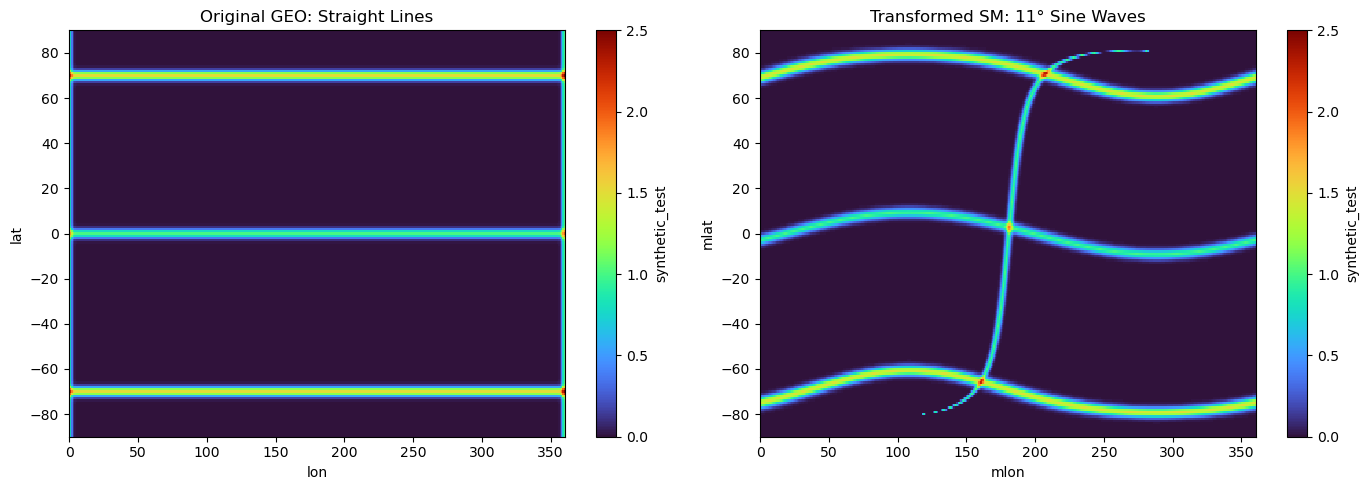

In [2]:
# 1. Create a Geographic (GEO) grid.
lats = np.linspace(-90, 90, 181)
lons = np.linspace(0, 360, 361)
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

# 2. Create synthetic data.
# A. A horizontal line across the Equator (0 N)
equator = np.exp(-(((lat_mesh - 0.0) / 2.0) ** 2))

# B. A horizontal line near the Geographic North Pole (70 N)
ring_70n = np.exp(-(((lat_mesh - 70.0) / 2.0) ** 2)) * 1.5

# C. A horizontal line near the Geographic South Pole (70 S)
ring_70s = np.exp(-(((lat_mesh + 70.0) / 2.0) ** 2)) * 1.5

# D. A vertical line down the Prime Meridian (0 / 360 Lon)
lon_dist = np.minimum(lon_mesh, 360 - lon_mesh)
prime_meridian = np.exp(-((lon_dist / 2.0) ** 2))

z_data = equator + ring_70n + ring_70s + prime_meridian

# 3. Package it into an Xarray DataArray with a specific time.
synthetic_da = xr.DataArray(
    data=z_data,
    coords={"lat": lats, "lon": lons},
    dims=["lat", "lon"],
    name="synthetic_test",
).assign_coords(time=np.datetime64("2025-11-11T00:00:00"))

# Plot data.
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: GEO data
synthetic_da.plot(ax=axs[0], x="lon", y="lat", cmap="turbo")
axs[0].set_title("Original GEO: Straight Lines")
axs[0].set_ylim(-90, 90)

# Plot 2: Transformed SM data
sm_synthetic = transform_geo_to_sm(synthetic_da)
sm_synthetic.plot(
    ax=axs[1],
    x="mlon",
    y="mlat",
    cmap="turbo",
    vmax=synthetic_da.max(),
)
axs[1].set_title("Transformed SM: 11° Sine Waves")
axs[1].set_ylim(-90, 90)

plt.tight_layout()
plt.show()

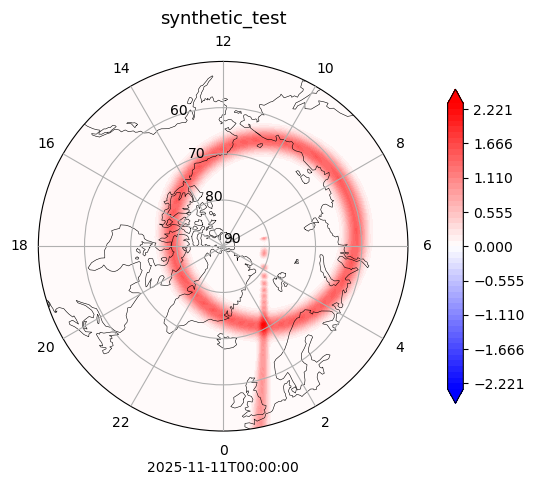

In [3]:
synthetic_da.ggcm.plot(
    coastlines=True,
    # stations=True,
    # highlight_station=current_station,
    # levels=levels,
    timestamp=True,
    mlt=True,
)

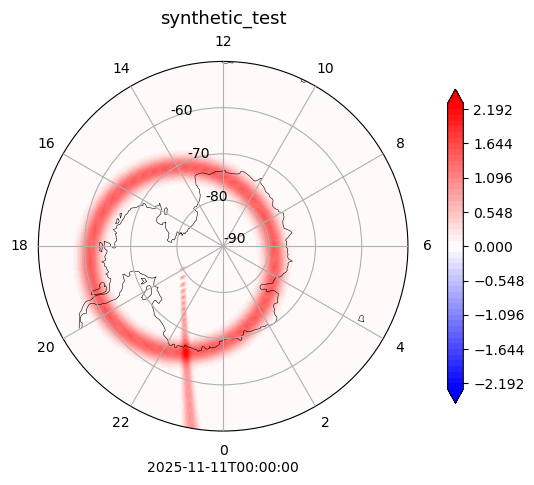

In [4]:
synthetic_da.ggcm.plot(
    lats_max=-50,
    lats_min=-90,
    coastlines=True,
    # stations=True,
    # highlight_station=current_station,
    # levels=levels,
    timestamp=True,
    mlt=True,
)